<a href="https://colab.research.google.com/github/dipalimhapsekar/CSL701-CE-28_Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Dipali Manohar Mhapsekar CE28

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# Task 1: Set Up the Python Environment

# Import NumPy for numerical and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Import files module for uploading
import zipfile # Added for zip file handling
import os # Added for path checking

csv_file_name = "cardekho_dataset.csv" # Corrected CSV file name
# `expected_zip_file_name` is no longer a strict match, but a base name to look for
expected_zip_base_name = "archive (1)"

try:
    # Attempt to read the CSV directly
    data = pd.read_csv(csv_file_name)
    print(f"Successfully loaded '{csv_file_name}'.")

except FileNotFoundError:
    print(f"The file '{csv_file_name}' was not found in the current Colab environment.")
    print("Please upload the file now. If you downloaded a '.zip' file, upload it and it will be extracted.")

    uploaded = files.upload()

    if csv_file_name in uploaded:
        print(f"File '{csv_file_name}' uploaded successfully. Attempting to read.")
        data = pd.read_csv(csv_file_name)
    else:
        found_zip_file = None
        for uploaded_filename in uploaded.keys():
            if expected_zip_base_name in uploaded_filename and uploaded_filename.endswith('.zip'):
                found_zip_file = uploaded_filename
                break

        if found_zip_file:
            print(f"'{found_zip_file}' uploaded. Attempting to extract and read '{csv_file_name}'.")
            with zipfile.ZipFile(found_zip_file, 'r') as zip_ref:
                zip_ref.extractall('.') # Extract all contents to the current directory

            # After extraction, try to read the CSV file
            if os.path.exists(csv_file_name):
                data = pd.read_csv(csv_file_name)
                print(f"Successfully extracted and loaded '{csv_file_name}' from '{found_zip_file}'.")
            else:
                print(f"'{csv_file_name}' not found inside '{found_zip_file}' after extraction.")
                print("Please ensure the correct CSV file is present in the zip or upload 'car_data.csv' directly.")
                raise FileNotFoundError(f"'{csv_file_name}' not found after extracting '{found_zip_file}'.")
        else:
            # If the user uploaded a different file or cancelled.
            print(f"Upload did not contain '{csv_file_name}' or a matching zip file (e.g., '{expected_zip_base_name}.zip') or was cancelled. Please ensure the correct file is uploaded.")
            raise # Re-raise the error as the file is still not found

# Display first 5 records
print("First 5 records:")
display(data.head())

# Number of rows and columns
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# Column names
print("Column names:")
print(data.columns.tolist())

# Data types
print("Data types:")
print(data.dtypes)

# Numerical attributes
print("Numerical attributes:")
print(data.select_dtypes(include=np.number).columns.tolist())

# Categorical attributes
print("Categorical attributes:")
print(data.select_dtypes(include="object").columns.tolist())

# Target variable
target = "selling_price"
y = data[target]

print("Target variable:", target)
print("Target shape:", y.shape)


Successfully loaded 'cardekho_dataset.csv'.
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Number of rows: 15411
Number of columns: 14
Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Data types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object
Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']
Target variable: selling_price
Target shape: (15411,)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Total missing values
print("\nTotal missing values:", data.isnull().sum().sum())

# Handle missing values if present
if data.isnull().sum().sum() > 0:
    # Remove rows containing missing values
    data = data.dropna().reset_index(drop=True)
    print("\nMissing-value rows removed.")
else:
    print("\nNo missing values found. No rows were removed.")

# Verify again
print("\nMissing values after preprocessing:")
print(data.isnull().sum())

print("\nFinal dataset shape:", data.shape)


Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values found. No rows were removed.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Final dataset shape: (15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Current year used for calculating car age
CURRENT_YEAR = 2026 # This variable is not used if we directly use 'vehicle_age'

# Create Car_Age
# Original code tried to use 'Year' which is not in the dataset.
# Using 'vehicle_age' column which already represents the car's age.
data["Car_Age"] = data["vehicle_age"]

# Select meaningful features
selected_features = [
    "km_driven",
    "fuel_type",
    "seller_type",
    "transmission_type",
    "Car_Age"
]

# Corrected target variable name
target = "selling_price"

X = data[selected_features].copy()
y = data[target].copy()

print("Selected features:")
print(selected_features)

print("\nTarget variable:")
print(target)

print("\nPredictor data:")
display(X.head())

print("\nTarget data:")
display(y.head())

Selected features:
['km_driven', 'fuel_type', 'seller_type', 'transmission_type', 'Car_Age']

Target variable:
selling_price

Predictor data:


,km_driven,fuel_type,seller_type,transmission_type,Car_Age
0,120000,Petrol,Individual,Manual,9
1,20000,Petrol,Individual,Manual,5
2,60000,Petrol,Individual,Manual,11
3,37000,Petrol,Individual,Manual,9
4,30000,Diesel,Dealer,Manual,6



Target data:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: One-hot encode categorical variables

categorical_features = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

# Perform one-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print("Transformed dataset:")
display(X_encoded.head())

print("\nTransformed columns:")
print(X_encoded.columns.tolist())

print("\nData types after encoding:")
print(X_encoded.dtypes)

# Verify that all predictors are numerical
print("\nAre all predictors numerical?")
print(all(np.issubdtype(dtype, np.number) for dtype in X_encoded.dtypes))

Transformed dataset:


,km_driven,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,120000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
1,20000,5,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,60000,11,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,37000,9,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,30000,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Transformed columns:
['km_driven', 'Car_Age', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Data types after encoding:
km_driven                         int64
Car_Age                           int64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical?
True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
data["Car_Age"] = data["vehicle_age"]

print(data[["vehicle_age", "Car_Age"]].head(10))

   vehicle_age  Car_Age
0            9        9
1            5        5
2           11       11
3            9        9
4            6        6
5            8        8
6            8        8
7            3        3
8            2        2
9            4        4


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

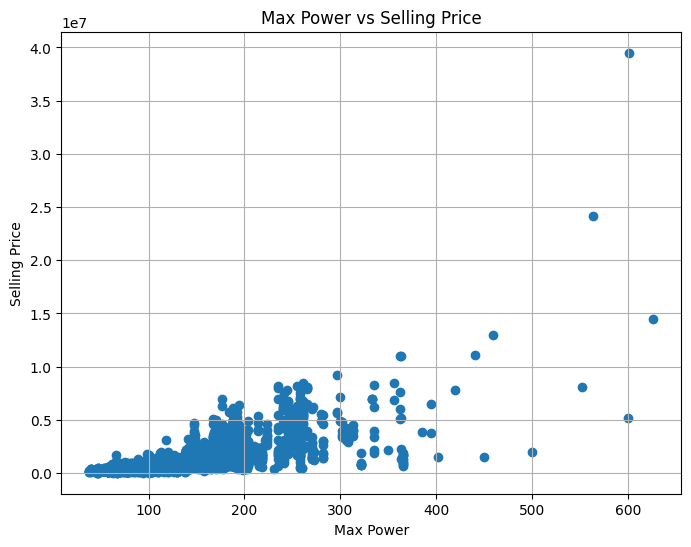

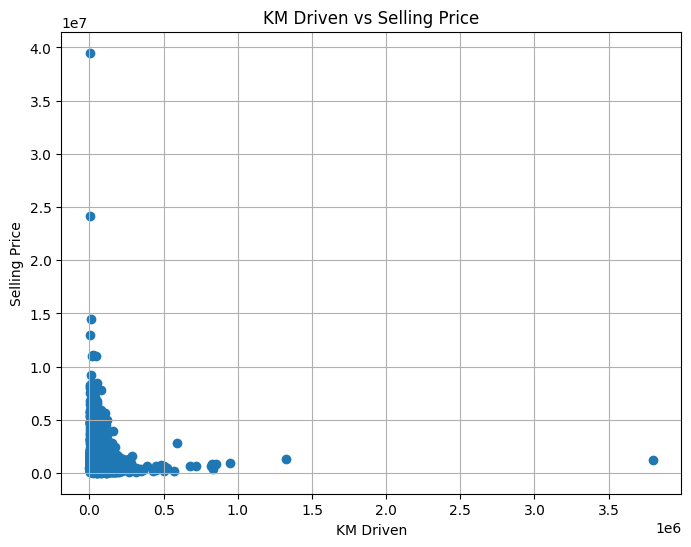

In [ ]:
# Task 7: Perform Exploratory Data Analysis

import matplotlib.pyplot as plt

# Scatter plot: Max_Power vs Selling_Price (using max_power as a relevant numerical feature)
plt.figure(figsize=(8, 6))
plt.scatter(data["max_power"], data["selling_price"])

plt.xlabel("Max Power")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")
plt.grid(True)
plt.show()


# Additional scatter plot: km_driven vs Selling_Price
plt.figure(figsize=(8, 6))
plt.scatter(data["km_driven"], data["selling_price"])

plt.xlabel("KM Driven")
plt.ylabel("Selling Price")
plt.title("KM Driven vs Selling Price")
plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Standardize Numerical Features

# Numerical features
numerical_features = ["km_driven", "Car_Age"]

# Calculate mean and standard deviation from training data
train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()

# Standardize training data
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize test data using training mean and std
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

print("Training Mean:")
print(train_mean)

print("\nTraining Standard Deviation:")
print(train_std)

print("\nStandardized Training Features:")
display(X_train.head())

print("\nStandardized Test Features:")
display(X_test.head())

print("\nSelling_Price is NOT standardized.")


# Target variable is NOT standardized
print("\nTarget variable Selling_Price is not standardized.")

Training Mean:
km_driven    55692.819598
Car_Age          6.032446
dtype: float64

Training Standard Deviation:
km_driven    54473.163748
Car_Age          3.018870
dtype: float64

Standardized Training Features:


,km_driven,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
3334,0.317719,1.976751,0.0,0.0,0.0,1.0,0.0,0.0,1.0
10928,0.042354,-0.673248,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2518,0.739946,0.320502,1.0,0.0,0.0,0.0,0.0,0.0,1.0
11322,-0.939781,-1.666997,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9394,0.115785,1.645501,0.0,0.0,0.0,1.0,0.0,0.0,1.0



Standardized Test Features:


,km_driven,Car_Age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
15384,-0.563448,-1.004497,1.0,0.0,0.0,0.0,0.0,0.0,0.0
147,0.409508,0.651752,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1668,0.124964,0.320502,1.0,0.0,0.0,0.0,0.0,0.0,1.0
11280,-0.563448,-0.341998,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13650,-0.618521,-1.004497,0.0,0.0,0.0,1.0,0.0,0.0,0.0



Selling_Price is NOT standardized.

Target variable Selling_Price is not standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Split the Dataset

# Fixed random seed for reproducibility
np.random.seed(42)

# Total number of observations
n = len(X_encoded)

# Create shuffled indices
indices = np.random.permutation(n)

# Calculate training size (80%)
train_size = int(0.80 * n)

# Split indices into training and testing
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing datasets
X_train = X_encoded.iloc[train_indices].copy()
X_test = X_encoded.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# Display number of observations
print("Total observations:", n)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# Display shapes
print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training feature shape: (12328, 9)
Testing feature shape: (3083, 9)

Training target shape: (12328,)
Testing target shape: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10: Construct the Feature Matrix

# Construct training feature matrix
Xtrain = X_train.to_numpy()

# Construct training target vector
ytrain = y_train.to_numpy()

# Construct testing feature matrix
Xtest = X_test.to_numpy()

# Construct testing target vector
ytest = y_test.to_numpy()


# Display shapes
print("Training feature matrix (Xtrain):", Xtrain.shape)
print("Training target vector (ytrain):", ytrain.shape)

print("\nTesting feature matrix (Xtest):", Xtest.shape)
print("Testing target vector (ytest):", ytest.shape)


# Number of rows
print("\nNumber of training observations:", Xtrain.shape[0])
print("Number of testing observations:", Xtest.shape[0])

# Number of predictor columns
print("Number of predictor columns:", Xtrain.shape[1])


# Verify that rows match
print("\nRows in Xtrain and ytrain:", Xtrain.shape[0], ytrain.shape[0])
print("Rows in Xtest and ytest:", Xtest.shape[0], ytest.shape[0])

Training feature matrix (Xtrain): (12328, 9)
Training target vector (ytrain): (12328,)

Testing feature matrix (Xtest): (3083, 9)
Testing target vector (ytest): (3083,)

Number of training observations: 12328
Number of testing observations: 3083
Number of predictor columns: 9

Rows in Xtrain and ytrain: 12328 12328
Rows in Xtest and ytest: 3083 3083


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add the Bias/Intercept Term

# Create a column of 1.0 for training data
ones_train = np.ones((Xtrain.shape[0], 1))

# Create a column of 1.0 for testing data
ones_test = np.ones((Xtest.shape[0], 1))

# Add the bias column to the feature matrices
Xtrain = np.hstack((ones_train, Xtrain))
Xtest = np.hstack((ones_test, Xtest))

# Verify new dimensions
print("Xtrain before bias: (12328, 9)")
print("Xtrain after bias:", Xtrain.shape)

print("\nXtest before bias: (3083, 9)")
print("Xtest after bias:", Xtest.shape)

# Display first 5 rows
print("\nFirst five rows of training matrix:")
print(Xtrain[:5])

Xtrain before bias: (12328, 9)
Xtrain after bias: (12328, 10)

Xtest before bias: (3083, 9)
Xtest after bias: (3083, 10)

First five rows of training matrix:
[[ 1.          0.31771939  1.97675102  0.          0.          0.
   1.          0.          0.          1.        ]
 [ 1.          0.04235444 -0.67324752  1.          0.          0.
   0.          1.          0.          1.        ]
 [ 1.          0.73994565  0.32050193  1.          0.          0.
   0.          0.          0.          1.        ]
 [ 1.         -0.93978055 -1.66699697  0.          0.          0.
   1.          0.          0.          0.        ]
 [ 1.          0.11578509  1.6455012   0.          0.          0.
   1.          0.          0.          1.        ]]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 12: Implement the OLS Function

def OLS(X, y):
    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate inverse of X^T X
    XTX_inv = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inv @ XTy

    # Return coefficient vector
    return beta


# Apply OLS on training data
beta = OLS(Xtrain, ytrain)

print("Regression coefficient vector:")
print(beta)

print("\nShape of coefficient vector:")
print(beta.shape)

Regression coefficient vector:
[1364952.28914411  -32045.52194534 -185214.43679563  420395.36269805
  511482.78858047  179332.49425458   -2380.03566546 -107967.82994885
 -128656.58427525 -942493.230646  ]

Shape of coefficient vector:
(10,)


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain.T @ Xtrain

# Calculate determinant of X^T X
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check whether the matrix is singular or nearly singular
tolerance = 1e-10

if np.isclose(det_XTX, 0, atol=tolerance):
    print("\nX^T X is singular or nearly singular.")
    print("Investigate the selected features for redundancy or multicollinearity.")
else:
    print("\nX^T X is non-singular.")
    print("The selected feature matrix can be used for OLS regression.")

Determinant of X^T X:
7.821466908510662e+28

X^T X is non-singular.
The selected feature matrix can be used for OLS regression.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Train the Regression Model

# Apply OLS function to training dataset
beta = OLS(Xtrain, ytrain)

# Display complete regression coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display intercept coefficient
print("\nIntercept coefficient (β0):")
print(beta[0])

# Feature names
feature_names = [
    "Intercept",
    "km_driven",
    "Car_Age",
    "fuel_type_Diesel",
    "fuel_type_Electric",
    "fuel_type_LPG",
    "fuel_type_Petrol",
    "seller_type_Individual",
    "seller_type_Trustmark Dealer",
    "transmission_type_Manual"
]

# Associate each coefficient with its feature
print("\nFeature-wise Regression Coefficients:")

for feature, coefficient in zip(feature_names, beta):
    print(f"{feature}: {coefficient}")

Regression Coefficient Vector (β):
[1364952.28914411  -32045.52194534 -185214.43679563  420395.36269805
  511482.78858047  179332.49425458   -2380.03566546 -107967.82994885
 -128656.58427525 -942493.230646  ]

Intercept coefficient (β0):
1364952.2891441062

Feature-wise Regression Coefficients:
Intercept: 1364952.2891441062
km_driven: -32045.52194534259
Car_Age: -185214.43679562997
fuel_type_Diesel: 420395.3626980531
fuel_type_Electric: 511482.78858046886
fuel_type_LPG: 179332.49425457604
fuel_type_Petrol: -2380.0356654584175
seller_type_Individual: -107967.82994884823
seller_type_Trustmark Dealer: -128656.58427524866
transmission_type_Manual: -942493.2306459951


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Interpret the Regression Coefficients

# Feature names
feature_names = [
    "Intercept",
    "km_driven",
    "Car_Age",
    "fuel_type_Diesel",
    "fuel_type_Electric",
    "fuel_type_LPG",
    "fuel_type_Petrol",
    "seller_type_Individual",
    "seller_type_Trustmark Dealer",
    "transmission_type_Manual"
]

# Create coefficient interpretation table
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta,
    "Sign": ["Positive" if value >= 0 else "Negative" for value in beta],
    "Absolute_Coefficient": np.abs(beta)
})

print("Coefficient Interpretation:")
display(coefficient_table)

# Rank features by absolute coefficient
importance = coefficient_table.iloc[1:].sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nFeatures ranked by absolute coefficient:")
display(importance)

Coefficient Interpretation:


,Feature,Coefficient,Sign,Absolute_Coefficient
0,Intercept,1.364952e+06,Positive,1.364952e+06
1,km_driven,-3.204552e+04,Negative,3.204552e+04
2,Car_Age,-1.852144e+05,Negative,1.852144e+05
3,fuel_type_Diesel,4.203954e+05,Positive,4.203954e+05
4,fuel_type_Electric,5.114828e+05,Positive,5.114828e+05
5,fuel_type_LPG,1.793325e+05,Positive,1.793325e+05
6,fuel_type_Petrol,-2.380036e+03,Negative,2.380036e+03
7,seller_type_Individual,-1.079678e+05,Negative,1.079678e+05
8,seller_type_Trustmark Dealer,-1.286566e+05,Negative,1.286566e+05
9,transmission_type_Manual,-9.424932e+05,Negative,9.424932e+05



Features ranked by absolute coefficient:


,Feature,Coefficient,Sign,Absolute_Coefficient
9,transmission_type_Manual,-942493.230646,Negative,942493.230646
4,fuel_type_Electric,511482.788580,Positive,511482.788580
3,fuel_type_Diesel,420395.362698,Positive,420395.362698
2,Car_Age,-185214.436796,Negative,185214.436796
5,fuel_type_LPG,179332.494255,Positive,179332.494255
8,seller_type_Trustmark Dealer,-128656.584275,Negative,128656.584275
7,seller_type_Individual,-107967.829949,Negative,107967.829949
1,km_driven,-32045.521945,Negative,32045.521945
6,fuel_type_Petrol,-2380.035665,Negative,2380.035665


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict Selling Prices

# Predict selling prices for the test dataset
y_pred = Xtest @ beta

# Display sample comparison
comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred
})

print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000,1.989451e+06
1,1290000,1.651511e+06
2,485000,7.794883e+05
3,400000,9.242533e+05
4,800000,1.568441e+06
5,150000,-1.414290e+05
6,650000,8.511355e+05
7,325000,2.754636e+05
8,300000,5.385211e+05
9,925000,8.370167e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
residuals = y_test - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display residuals
print("Residuals:")
print(residuals)

# Display RSS
print("\nResidual Sum of Squares (RSS):", RSS)

Residuals:
15384    2.460549e+06
147     -3.615109e+05
1668    -2.944883e+05
11280   -5.242533e+05
13650   -7.684405e+05
             ...     
5191    -7.611415e+04
13418    1.356371e+05
5390    -2.374701e+04
860     -7.141749e+04
7270    -5.571187e+05
Name: selling_price, Length: 3083, dtype: float64

Residual Sum of Squares (RSS): 1681040269901908.8


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Calculate the mean of actual test values
y_test_mean = np.mean(y_test)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((y_test - y_test_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS and R²
print("Total Sum of Squares (TSS):", TSS)
print("R² Score:", R2)

# Interpretation
print("\nInterpretation:")
print(f"The R² value is {R2:.4f}.")
print("This indicates the proportion of variation in used-car selling prices")
print("that is explained by the selected features in the regression model.")

Total Sum of Squares (TSS): 2407385049859876.5
R² Score: 0.30171524908333425

Interpretation:
The R² value is 0.3017.
This indicates the proportion of variation in used-car selling prices
that is explained by the selected features in the regression model.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


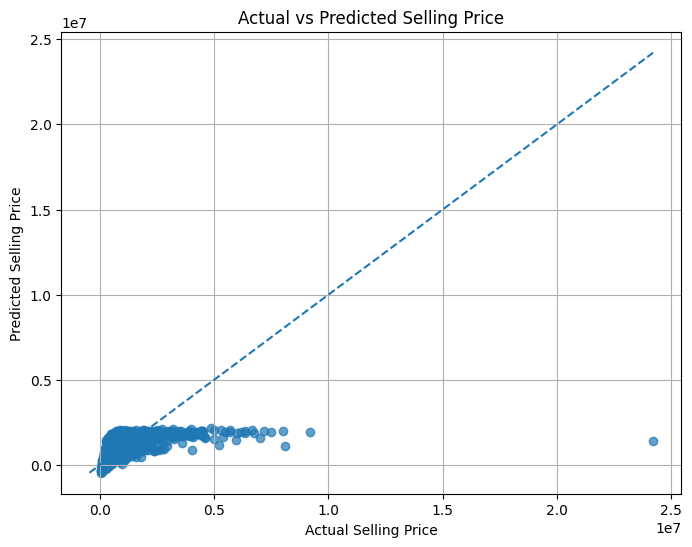

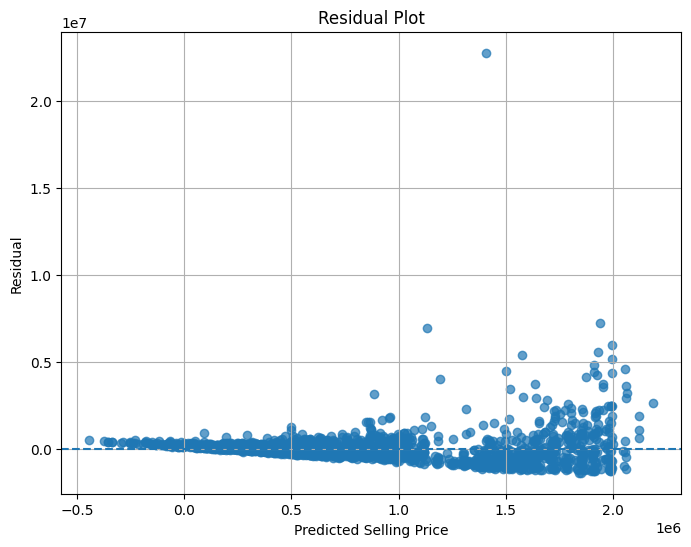

Observations with relatively large prediction errors:
Index: 2796, Actual: 24200000.00, Predicted: 1409121.20, Error: 22790878.80
Index: 2362, Actual: 9200000.00, Predicted: 1937217.17, Error: 7262782.83
Index: 1552, Actual: 8100000.00, Predicted: 1134268.52, Error: 6965731.48
Index: 1382, Actual: 8000000.00, Predicted: 1995333.87, Error: 6004666.13
Index: 841, Actual: 7500000.00, Predicted: 1930381.93, Error: 5569618.07


In [ ]:
# Plot Actual vs Predicted Selling Price
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

# Reference line for perfect prediction
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value],
         [min_value, max_value],
         linestyle='--')

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


# Identify observations with large prediction errors
absolute_errors = np.abs(residuals)

# Display top 5 observations with largest errors
large_error_indices = np.argsort(absolute_errors)[-5:][::-1]

print("Observations with relatively large prediction errors:")
for i in large_error_indices:
    print(f"Index: {i}, Actual: {y_test.iloc[i]:.2f}, "
          f"Predicted: {y_pred[i]:.2f}, "
          f"Error: {residuals.iloc[i]:.2f}")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.